Feature dataset saved as 'matches_2000_onwards_features_fifa.csv'


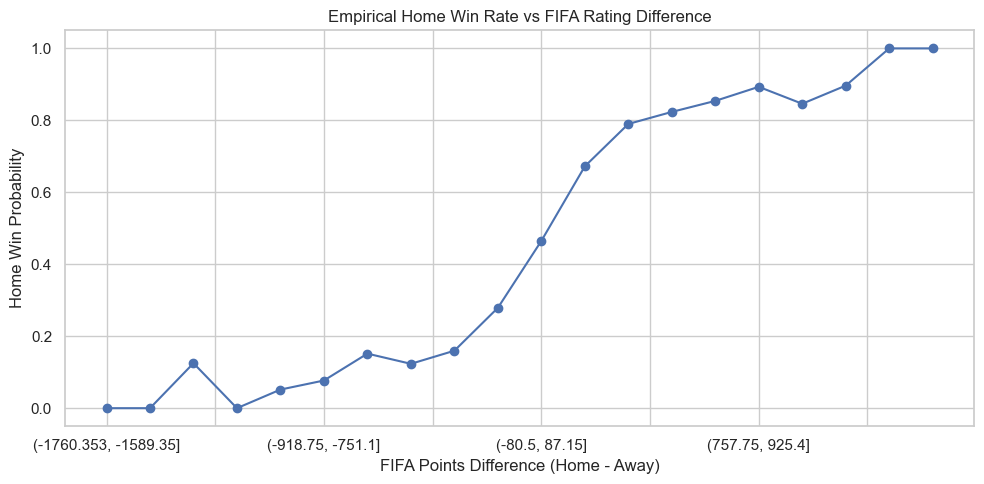

In [ ]:
# ============================================================
# 02_feature_engineering.ipynb
# Feature engineering using FIFA rankings, form, H2H and penalties
# ============================================================

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# LOAD MATCH DATA (2000+)
# =========================
matches = pd.read_csv(
    "../data/processed/results_2000_onwards.csv",
    parse_dates=["date"]
)

# Basic outcome labels
matches["home_win"] = (matches["home_score"] > matches["away_score"]).astype(int)
matches["draw"] = (matches["home_score"] == matches["away_score"]).astype(int)
matches["away_win"] = (matches["home_score"] < matches["away_score"]).astype(int)

matches = matches.sort_values("date").reset_index(drop=True)
matches.head()


# =========================
# 1️⃣ Load FIFA ranking (historical)
# =========================
fifa = pd.read_csv(
    "../data/raw/fifa_world_rankings.csv",
    parse_dates=["date"]
)

fifa = fifa.rename(columns={
    "date": "ranking_date",
    "country": "team",
    "total_points": "fifa_points"
})

fifa = fifa[["ranking_date", "team", "fifa_points"]]
fifa = fifa.sort_values("ranking_date")

fifa.head()


# =========================
# 2️⃣ Merge closest FIFA ranking (as-of join)
# =========================
matches = matches.sort_values("date")

# Home team FIFA points
matches = pd.merge_asof(
    matches,
    fifa.rename(columns={
        "team": "home_team",
        "fifa_points": "home_fifa_points"
    }),
    by="home_team",
    left_on="date",
    right_on="ranking_date",
    direction="backward"
)

# Away team FIFA points
matches = pd.merge_asof(
    matches,
    fifa.rename(columns={
        "team": "away_team",
        "fifa_points": "away_fifa_points"
    }),
    by="away_team",
    left_on="date",
    right_on="ranking_date",
    direction="backward"
)

matches["fifa_diff"] = matches["home_fifa_points"] - matches["away_fifa_points"]

matches[["home_team", "away_team", "home_fifa_points", "away_fifa_points"]].head()


# =========================
# 3️⃣ Recent form (last 5 matches)
# =========================
N_LAST = 5
team_form = {}

matches["home_last5_win_rate"] = np.nan
matches["away_last5_win_rate"] = np.nan

for idx, row in matches.iterrows():
    home, away = row["home_team"], row["away_team"]

    # Home form
    matches.at[idx, "home_last5_win_rate"] = (
        np.mean(team_form.get(home, [0.5])) if home in team_form else 0.5
    )

    # Away form
    matches.at[idx, "away_last5_win_rate"] = (
        np.mean(team_form.get(away, [0.5])) if away in team_form else 0.5
    )

    # Update form history
    home_result = 1 if row["home_win"] else 0.5 if row["draw"] else 0
    away_result = 1 if row["away_win"] else 0.5 if row["draw"] else 0

    team_form.setdefault(home, []).append(home_result)
    team_form.setdefault(away, []).append(away_result)

    team_form[home] = team_form[home][-N_LAST:]
    team_form[away] = team_form[away][-N_LAST:]


# =========================
# 4️⃣ Head-to-head (historical matchups)
# =========================
h2h = {}

matches["h2h_home_win_rate"] = 0.5
matches["h2h_draw_rate"] = 0.0
matches["h2h_matches_played"] = 0

for idx, row in matches.iterrows():
    home, away = row["home_team"], row["away_team"]
    key = tuple(sorted([home, away]))

    stats = h2h.get(key, {"home_wins":0, "away_wins":0, "draws":0, "matches":0})

    if stats["matches"] > 0:
        matches.at[idx, "h2h_home_win_rate"] = stats["home_wins"] / stats["matches"]
        matches.at[idx, "h2h_draw_rate"] = stats["draws"] / stats["matches"]
        matches.at[idx, "h2h_matches_played"] = stats["matches"]

    # Update stats AFTER match
    stats["matches"] += 1
    if row["home_win"]:
        stats["home_wins"] += 1
    elif row["away_win"]:
        stats["away_wins"] += 1
    else:
        stats["draws"] += 1

    h2h[key] = stats


# =========================
# 5️⃣ Penalty shootouts performance
# =========================
shootouts = pd.read_csv("../data/raw/shootouts.csv", parse_dates=["date"]).loc[lambda x: x['date'].dt.year >= 2000]

penalty_wins = shootouts["winner"].value_counts()
penalty_games = pd.concat([
    shootouts["home_team"],
    shootouts["away_team"]
]).value_counts()


penalty_win_rate = (penalty_wins / penalty_games).fillna(0.5)

matches["home_penalty_win_rate"] = matches["home_team"].map(penalty_win_rate).fillna(0.5)
matches["away_penalty_win_rate"] = matches["away_team"].map(penalty_win_rate).fillna(0.5)


# =========================
# 6️⃣ Final dataset & save
# =========================
final_features = [
    "date", "home_team", "away_team", "neutral",
    "home_fifa_points", "away_fifa_points", "fifa_diff",
    "home_last5_win_rate", "away_last5_win_rate",
    "h2h_home_win_rate", "h2h_draw_rate", "h2h_matches_played",
    "home_penalty_win_rate", "away_penalty_win_rate",
    "home_win", "draw", "away_win",
    "year"
]

final_df = matches[final_features].dropna().reset_index(drop=True)

final_df.to_csv(
    "../data/processed/matches_2000_onwards_features_fifa.csv",
    index=False
)

print("Feature dataset saved as 'matches_2000_onwards_features_fifa.csv'")


# ============================================================
# 📊 BONUS VISUALIZATION (Exploratory, Non-intrusive)
# ============================================================
# Relationship between FIFA rating difference and empirical home win rate

bins = pd.cut(final_df["fifa_diff"], bins=20)
home_win_by_diff = final_df.groupby(bins)["home_win"].mean()

plt.figure(figsize=(10, 5))
home_win_by_diff.plot(marker="o")
plt.title("Empirical Home Win Rate vs FIFA Rating Difference")
plt.xlabel("FIFA Points Difference (Home - Away)")
plt.ylabel("Home Win Probability")
plt.tight_layout()
plt.show()
